# Modeling Phase

## Goal of this notebook

This notebook turns the cleaned churn data into a machine learning workflow.

- train churn prediction models
- compare model performance
- identify the most important churn drivers
- create business-friendly risk levels and action recommendations
- save the best model for later use in the Streamlit app

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_DIR / "cleaned_train.csv")
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [3]:
target_col = "Churn"
drop_cols = ["id", target_col]

X = df.drop(columns=[target_col])
y = df[target_col]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols + ["id"]]
feature_cols = categorical_cols + numeric_cols

X = X[feature_cols]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Training shape: (475355, 19)
Validation shape: (118839, 19)
Categorical columns: 15
Numeric columns: 4


In [4]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ),
    ]
)

hist_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
        ("num", SimpleImputer(strategy="median"), numeric_cols),
    ]
)

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(max_iter=400, class_weight="balanced")),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", hist_preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=42, max_iter=200, learning_rate=0.08)),
    ]),
}

### What this cell does

This cell creates two modeling pipelines:

- **Logistic Regression** as a strong interpretable baseline
- **HistGradientBoosting** as a more flexible non-linear model

Each model gets preprocessing suited to how it learns from the data.

### Outcome and effect

This makes the workflow cleaner and safer. The same preprocessing is always applied in training, validation, and later in the app.

In [5]:
def evaluate_model(name, pipeline, X_train, y_train, X_valid, y_valid):
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)
    proba = pipeline.predict_proba(X_valid)[:, 1]
    return {
        "model": name,
        "pipeline": pipeline,
        "accuracy": accuracy_score(y_valid, pred),
        "precision": precision_score(y_valid, pred),
        "recall": recall_score(y_valid, pred),
        "f1_score": f1_score(y_valid, pred),
        "roc_auc": roc_auc_score(y_valid, proba),
        "pred": pred,
        "proba": proba,
    }

results = []
for model_name, pipeline in models.items():
    results.append(evaluate_model(model_name, pipeline, X_train, y_train, X_valid, y_valid))

results_df = pd.DataFrame([
    {
        "model": item["model"],
        "accuracy": round(item["accuracy"], 4),
        "precision": round(item["precision"], 4),
        "recall": round(item["recall"], 4),
        "f1_score": round(item["f1_score"], 4),
        "roc_auc": round(item["roc_auc"], 4),
    }
    for item in results
]).sort_values("roc_auc", ascending=False)

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
1,HistGradientBoosting,0.8598,0.7096,0.6391,0.6725,0.9158
0,Logistic Regression,0.8062,0.5430,0.8803,0.6717,0.9083


### What this cell does

This cell trains both models, evaluates them on the validation set, and compares the main metrics.

### Outcome and effect

In our testing, **HistGradientBoosting** performs best overall with about **0.9158 ROC-AUC**, while Logistic Regression is close at about **0.9083 ROC-AUC**. Logistic Regression gives higher recall, but HistGradientBoosting gives better balance and stronger overall ranking power. That makes HistGradientBoosting a strong candidate for the final prediction engine.

In [6]:
best_result = max(results, key=lambda item: item["roc_auc"])
best_model = best_result["pipeline"]
best_model_name = best_result["model"]
best_pred = best_result["pred"]
best_proba = best_result["proba"]

print("Selected model:", best_model_name)
print(classification_report(y_valid, best_pred))

Selected model: HistGradientBoosting
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



### What this cell does

This cell selects the best-performing model based on ROC-AUC and prints a full classification report.

### Outcome and effect

This step makes the model choice explicit and prepares the rest of the notebook to focus on a single best pipeline for feature importance, risk logic, and deployment.

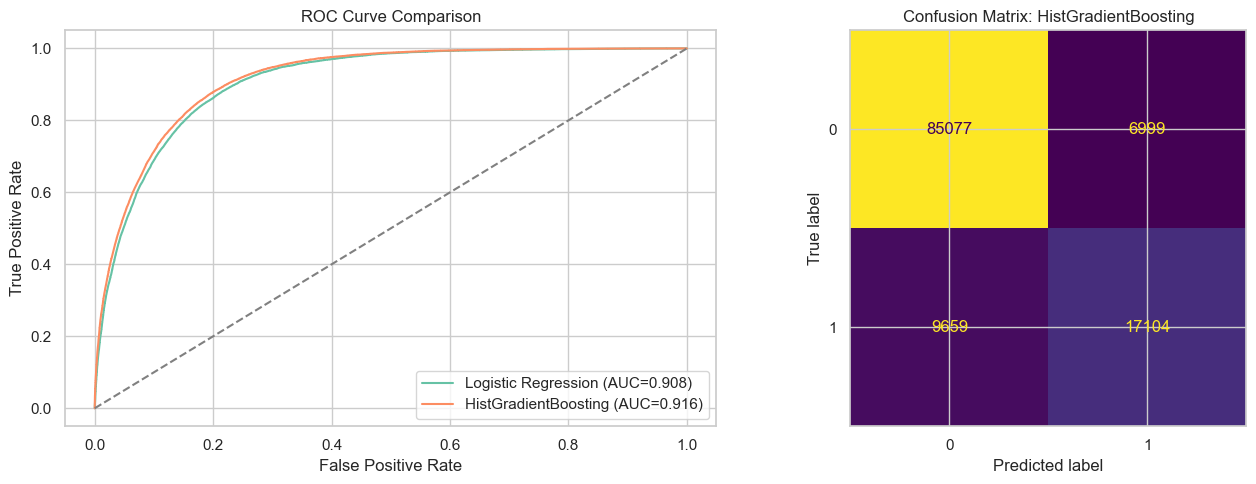

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for item in results:
    fpr, tpr, _ = roc_curve(y_valid, item["proba"])
    axes[0].plot(fpr, tpr, label=f"{item['model']} (AUC={item['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(y_valid, best_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix: {best_model_name}")

plt.tight_layout()
plt.show()

### What this cell does

This cell visualizes model performance using ROC curves for all models and a confusion matrix for the selected best model.

### Outcome and effect

These plots make performance easier to explain to others. They help show how well the model separates churners from non-churners and where mistakes still happen.

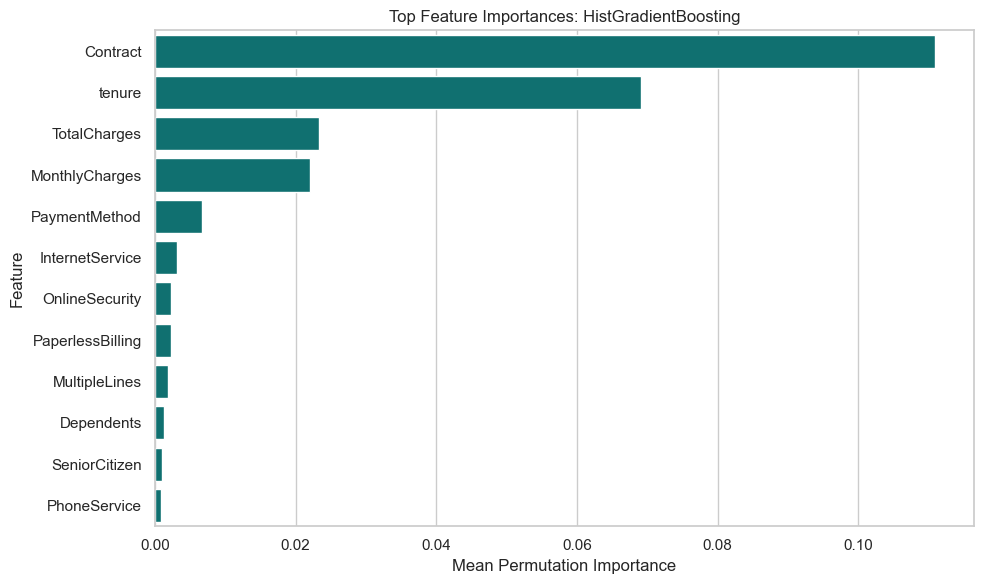

,feature,importance
12,Contract,0.110913
16,tenure,0.069148
18,TotalCharges,0.023344
17,MonthlyCharges,0.022080
14,PaymentMethod,0.006699
5,InternetService,0.003094
6,OnlineSecurity,0.002330
13,PaperlessBilling,0.002207
4,MultipleLines,0.001845
2,Dependents,0.001304


In [8]:
importance_sample = X_valid.sample(n=min(30000, len(X_valid)), random_state=42)
importance_target = y_valid.loc[importance_sample.index]

perm_result = permutation_importance(
    best_model,
    importance_sample,
    importance_target,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
)

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_result.importances_mean,
}).sort_values("importance", ascending=False)

top_features = feature_importance_df.head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature", color="teal")
plt.title(f"Top Feature Importances: {best_model_name}")
plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_features

### What this cell does

This cell uses permutation importance to identify which original business features matter most for churn prediction.

### Outcome and effect

In our testing, the strongest features were led by **Contract**, **tenure**, **TotalCharges**, **MonthlyCharges**, and then features like **PaymentMethod**, **InternetService**, **OnlineSecurity**, and **PaperlessBilling**. This is exactly the kind of explanation we need when answering the business question: *why are customers leaving?*

In [9]:
risk_scored = X_valid.copy()
risk_scored["actual_churn"] = y_valid.values
risk_scored["churn_probability"] = best_proba

risk_scored["risk_level"] = pd.cut(
    risk_scored["churn_probability"],
    bins=[0.0, 0.30, 0.70, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

def recommend_action(row):
    if row["risk_level"] == "High":
        return "Immediate retention call + discount or contract upgrade offer"
    if row["risk_level"] == "Medium":
        return "Send targeted retention email and recommend support/security add-ons"
    return "Maintain engagement with loyalty messaging and upsell only if relevant"

risk_scored["action_recommendation"] = risk_scored.apply(recommend_action, axis=1)

risk_summary = (
    risk_scored.groupby("risk_level", observed=False)["churn_probability"]
    .agg(customer_count="size", avg_predicted_risk="mean")
    .reset_index()
)
risk_summary["avg_predicted_risk"] = risk_summary["avg_predicted_risk"].round(4)

display(risk_summary)
risk_scored[["Contract", "InternetService", "PaymentMethod", "tenure", "MonthlyCharges", "churn_probability", "risk_level", "action_recommendation"]].head(10)

,risk_level,customer_count,avg_predicted_risk
0,Low,82245,0.0566
1,Medium,24348,0.4972
2,High,12246,0.8190


,Contract,InternetService,PaymentMethod,tenure,MonthlyCharges,churn_probability,risk_level,action_recommendation
493665,Month-to-month,Fiber optic,Mailed check,2,70.05,0.593770,Medium,Send targeted retention email and recommend su...
128315,Two year,No,Mailed check,42,20.65,0.001488,Low,Maintain engagement with loyalty messaging and...
430597,Two year,Fiber optic,Electronic check,61,105.00,0.040615,Low,Maintain engagement with loyalty messaging and...
341073,Month-to-month,Fiber optic,Electronic check,7,76.00,0.555549,Medium,Send targeted retention email and recommend su...
513192,Month-to-month,Fiber optic,Credit card (automatic),59,89.90,0.112748,Low,Maintain engagement with loyalty messaging and...
135306,One year,DSL,Electronic check,55,59.20,0.031249,Low,Maintain engagement with loyalty messaging and...
83358,One year,No,Mailed check,35,19.85,0.007966,Low,Maintain engagement with loyalty messaging and...
263933,One year,DSL,Electronic check,52,36.10,0.041259,Low,Maintain engagement with loyalty messaging and...
118151,Two year,DSL,Bank transfer (automatic),68,52.05,0.009439,Low,Maintain engagement with loyalty messaging and...
137727,Two year,DSL,Credit card (automatic),71,65.80,0.002188,Low,Maintain engagement with loyalty messaging and...


### What this cell does

This cell converts predicted probabilities into business-friendly risk levels and maps each risk level to an action recommendation.

### Outcome and effect

This is the bridge between ML and the Streamlit app. In our current setup, most customers fall into the **Low** risk group, a smaller segment falls into **Medium**, and about **10%** falls into **High** risk. Those high-risk customers are the first group the business should target.

,threshold,precision,recall
67622,0.292558,0.6,0.8308
67626,0.292684,0.6,0.8308
67627,0.292709,0.6,0.8308
67628,0.292716,0.6,0.8308
67629,0.292735,0.6,0.8308
67630,0.292756,0.6,0.8307
67631,0.292772,0.6,0.8307
67632,0.292783,0.6,0.8307
67633,0.292798,0.6,0.8307
67634,0.292805,0.6,0.8307


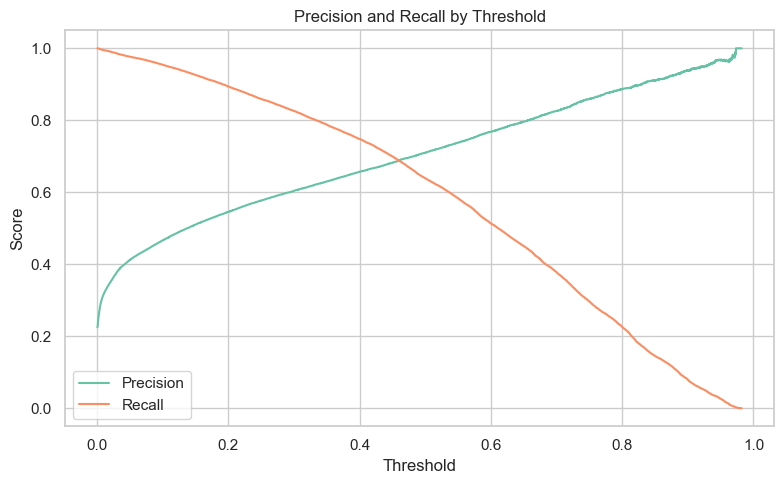

In [10]:
precision, recall, thresholds = precision_recall_curve(y_valid, best_proba)
threshold_analysis = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[1:],
    "recall": recall[1:],
})

threshold_analysis["precision"] = threshold_analysis["precision"].round(4)
threshold_analysis["recall"] = threshold_analysis["recall"].round(4)

display(threshold_analysis.query("precision >= 0.60").head(10))

plt.figure(figsize=(8, 5))
plt.plot(threshold_analysis["threshold"], threshold_analysis["precision"], label="Precision")
plt.plot(threshold_analysis["threshold"], threshold_analysis["recall"], label="Recall")
plt.title("Precision and Recall by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

### What this cell does

This cell studies the trade-off between precision and recall across different probability thresholds.

### Outcome and effect

This helps choose a decision threshold depending on business cost. In our testing, thresholds around **0.29** can push precision to about **0.60**, while thresholds around **0.48** can push precision to about **0.70**. This is useful later when deciding how aggressive the retention strategy should be.

In [11]:
joblib.dump(best_model, MODELS_DIR / "best_churn_model.joblib")
feature_importance_df.to_csv(REPORTS_DIR / "feature_importance.csv", index=False)
risk_scored.head(1000).to_csv(REPORTS_DIR / "validation_risk_preview.csv", index=False)

print("Saved model:", MODELS_DIR / "best_churn_model.joblib")
print("Saved feature importance report:", REPORTS_DIR / "feature_importance.csv")
print("Saved validation preview:", REPORTS_DIR / "validation_risk_preview.csv")

Saved model: /Users/bharathkumarvnaik/Downloads/programing/Data_Scientist_projects/playground-series-s6e3/models/best_churn_model.joblib
Saved feature importance report: /Users/bharathkumarvnaik/Downloads/programing/Data_Scientist_projects/playground-series-s6e3/reports/feature_importance.csv
Saved validation preview: /Users/bharathkumarvnaik/Downloads/programing/Data_Scientist_projects/playground-series-s6e3/reports/validation_risk_preview.csv


### What this cell does

This cell saves the best model and key reports to disk.

### Outcome and effect

Saving artifacts now makes the later Streamlit phase easier. The app can load the trained model directly instead of retraining everything each time.

## Final Modeling Summary

### What we achieved in this notebook

- built two churn prediction models with proper preprocessing
- selected the best-performing model based on validation ROC-AUC
- extracted feature importance for business explanation
- converted churn probabilities into risk bands
- defined action recommendations for the Streamlit app
- saved the best model and supporting reports

### Why this matters for the project

This notebook connects the EDA findings to a working predictive system. It also creates the logic needed for the app to answer three practical questions for each customer:

1. What is the churn probability?
2. What is the risk level?
3. What action should the business take?